# Inverse Gaussian Distribution

`InverseGaussian(mean, shape)` is a continuous distribution on the positive numbers, also called the Wald distribution. It is the first time a Brownian motion with positive drift reaches a fixed level, which is why it turns up as a model for waiting times and durations.

Despite the name it is **not** the reciprocal of a normal random variable. The "inverse" refers to a relationship between the cumulant generating functions, not to `1 / X`.

In [1]:
from symbulate import *

## Draw a value from an inverse Gaussian distribution

In [2]:
InverseGaussian(mean=2, shape=3).draw()

1.1451141511651999

## Theoretical mean, variance, and standard deviation

The `mean` parameter really is the mean, and the variance is `mean**3 / shape`.

In [3]:
X = InverseGaussian(mean=2, shape=3)
X.mean(), X.var(), X.sd()

(np.float64(2.0),
 np.float64(2.666666666666666),
 np.float64(1.6329931618554518))

In [4]:
# var = mean**3 / shape
2**3 / 3

2.6666666666666665

## Assign and simulate a random variable

In [5]:
W = RV(InverseGaussian(mean=2, shape=3))
W.sim(10000)

0,2.5441
1,1.1438
2,2.4436
3,4.7670
4,2.4236
5,0.5985
6,0.3473
7,1.8665
8,2.2326
...,...
9999,2.4955


In [6]:
sims = W.sim(10000)
sims.mean(), sims.sd()

(1.9987225468992147, 1.6333307786408622)

## Plot the pdf

The support is the positive numbers, and the shape is right-skewed: a sharp rise, a peak below the mean, then a long right tail.

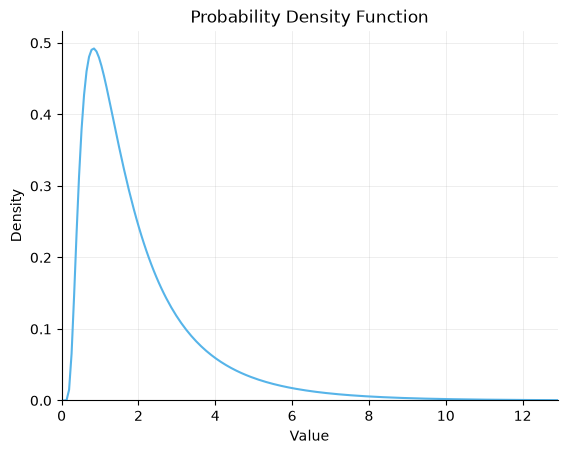

In [7]:
InverseGaussian(mean=2, shape=3).plot()

## Plot the CDF

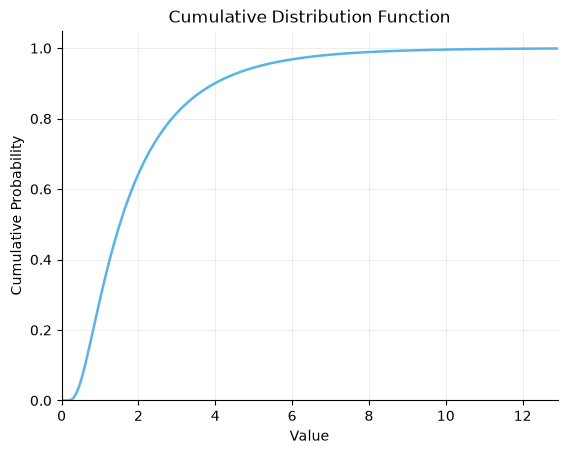

In [8]:
InverseGaussian(mean=2, shape=3).plot(cdf=True)

## Simulation against the exact pdf

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density (Estimated) (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


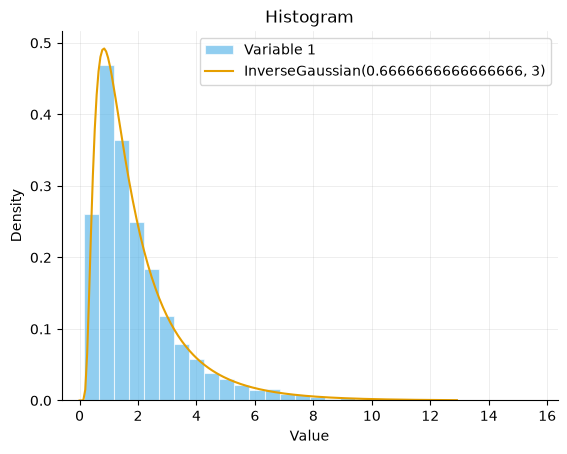

In [9]:
W.sim(10000).plot()
InverseGaussian(mean=2, shape=3).plot()

## The shape parameter controls the skew

With `mean` held fixed, a small `shape` gives a heavily skewed, spread-out distribution; a large one pulls it in tight around the mean.

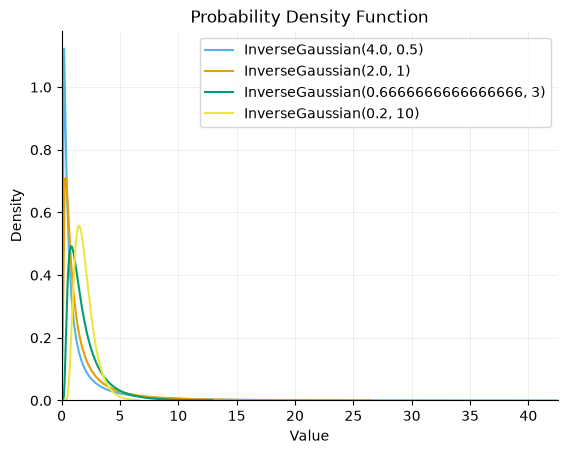

In [10]:
for s in [0.5, 1, 3, 10]:
    InverseGaussian(mean=2, shape=s).plot()

In [11]:
# A right-skewed distribution has its median below its mean. The gap shrinks
# as the shape grows and the curve straightens out toward a normal.
for s in [0.5, 1, 3, 10, 100]:
    d = InverseGaussian(mean=2, shape=s)
    gap = float(d.mean()) - float(d.median())
    print(f"shape={s:>5}  sd={float(d.sd()):.4f}  mean - median={gap:.4f}")

shape=  0.5  sd=4.0000  mean - median=1.3016
shape=    1  sd=2.8284  mean - median=0.9715
shape=    3  sd=1.6330  mean - median=0.4877
shape=   10  sd=0.8944  mean - median=0.1796
shape=  100  sd=0.2828  mean - median=0.0198


## As the shape grows, it approaches a normal distribution

Letting `shape` run to infinity with `mean` fixed sends the variance (`mean**3 / shape`) to 0 and the skew to 0, so the distribution tends to `Normal(mean, ...)`. Here is a large shape plotted against the matching normal.

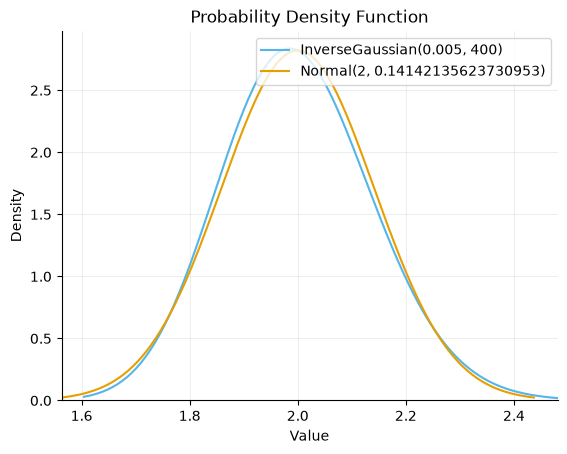

In [12]:
big = InverseGaussian(mean=2, shape=400)
big.plot()
Normal(mean=2, sd=float(big.sd())).plot()

## Where it comes from: a first passage time

An inverse Gaussian value is the first time a Brownian motion with positive drift reaches a level. Symbulate can simulate that directly with `hitting_time`, so the story can be checked rather than asserted.

For a drifting Brownian motion `drift * t + scale * B(t)` first reaching `level`, the hitting time is `InverseGaussian` with `mean = level / drift` and `shape = (level / scale) ** 2`.

In [13]:
level, drift, scale = 2.0, 1.0, 1.0

# The matching inverse Gaussian for these Brownian parameters.
matching = InverseGaussian(mean=level / drift, shape=(level / scale) ** 2)
matching.mean(), matching.sd()

(np.float64(2.0), np.float64(1.4142135623730951))

In [14]:
seed(42)
B = BrownianMotion(drift=drift, scale=scale)
times = hitting_time(B, level=level, max_time=200).sim(2000)
times.mean(), times.sd()

Simulating... [██████████████████████████████] 2000/2000 (100%)


(2.0828536171913146, 1.466129804341018)

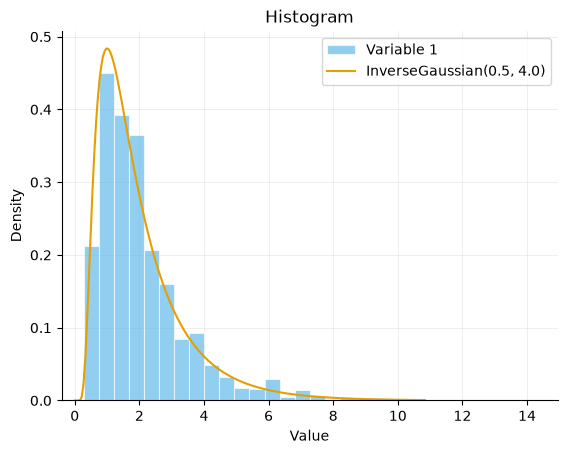

In [15]:
times.plot()
matching.plot()